In [3]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")


task_grn_inference_dir = "../../"
output_dir = '../output/motif_analysis'

par = {
    'motif_scores_db': f"{task_grn_inference_dir}/task_grn_inference/resources/supp_data/db.regions_vs_motifs.scores.feather",
    'motifs_info': f'{task_grn_inference_dir}/task_grn_inference/resources/supp_data/motifs-v10-nr.hgnc-m0.00001-o0.0.tbl',
    'annotation_file': f'{task_grn_inference_dir}/task_grn_inference/resources/supp_data/gencode.v45.annotation.gtf.gz',
    'atac': f'{task_grn_inference_dir}/task_grn_inference/resources/grn_benchmark/inference_data/op_atac.h5ad', # to get consensus peaks
    'output_dir': f'{output_dir}',
    'consensus_peak': f'{output_dir}/consensus_peak.csv', # where consensus peaks are stored,
    'enhancer_distance': 150_000,  #TODO: this should be distance free
    'promoter_df': f'{output_dir}/promoters.csv',
    'regions2promoters': f'{output_dir}/regions2promoters.csv',
    'tf2gene': f'{output_dir}/tf2gene.csv',
}

In [9]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /vol/biotools/alma8/R-4.2.0/lib64/R
INFO:rpy2.situation:R library path: /vol/biotools/alma8/R-4.2.0/lib64/R/lib:/usr/local/lib64:/usr/lib/jvm/java-1.8.0-openjdk-1.8.0.332.b09-1.el8_5.x86_64/jre/lib/amd64/server:/home/jnourisa/cuda-12.3/lib64:/home/jnourisa/cuda-12.3/lib64:/usr/lib64/openmpi/lib:
INFO:rpy2.situation:LD_LIBRARY_PATH: /home/jnourisa/cuda-12.3/lib64:/home/jnourisa/cuda-12.3/lib64:/usr/lib64/openmpi/lib
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
During startup - Warning message:
package ‘stats’ in options("defaultPackages") was not found 
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [10]:
%%R
x <- rnorm(100)
summary(x)

  Graphics API version mismatch



RRuntimeError: Error in (function (filename = "Rplot%03d.png", width = 480, height = 480,  : 
  Graphics API version mismatch


In [ ]:
import subprocess
subprocess.run(
    ["python", "../src/motif_analysis/script.py", f"--output_dir={output_dir}", f"--task_grn_inference_dir={task_grn_inference_dir}"],
    check=True,  # Raise an exception if the command fails
    text=True  # Capture stdout and stderr as text
)

Running tf2gene...


In [6]:
tf2gene = pd.read_csv(par['tf2gene'])


,tf,motif,region,score,gene_name,promoter_open
0,TGIF1,hdpi__TGIF1,chr10:100000176-100000504,2.77,DNMBP-AS1,True
1,TGIF1,hdpi__TGIF1,chr10:100000176-100000504,2.77,DNMBP,True
2,TGIF1,hdpi__TGIF1,chr10:100054120-100054409,4.21,DNMBP-AS1,True
3,TGIF1,hdpi__TGIF1,chr10:100054120-100054409,4.21,DNMBP,True
4,TGIF1,hdpi__TGIF1,chr10:100054120-100054409,4.21,ERLIN1,True


In [ ]:
df_sub = tf2gene[tf2gene['gene_name'].isin(['IFIMT2', 'IFIMT3', 'FCER1G'])]

In [ ]:
df_sub[df_sub['tf']=='TGIF1']

,tf,motif,region,score,gene_name,promoter_open
144338,TGIF1,hdpi__TGIF1,chr1:161133682-161133922,4.79,FCER1G,True
144364,TGIF1,hdpi__TGIF1,chr1:161193962-161194306,3.53,FCER1G,True
144381,TGIF1,hdpi__TGIF1,chr1:161215036-161215382,3.31,FCER1G,True
144398,TGIF1,hdpi__TGIF1,chr1:161216726-161216961,2.89,FCER1G,True
144415,TGIF1,hdpi__TGIF1,chr1:161226898-161227130,2.86,FCER1G,True
...,...,...,...,...,...,...
166035367,TGIF1,tfdimers__MD00287,chr1:161215036-161215382,2.39,FCER1G,True
166036421,TGIF1,tfdimers__MD00287,chr1:161216979-161217299,2.73,FCER1G,True
166037351,TGIF1,tfdimers__MD00287,chr1:161260648-161260975,4.82,FCER1G,True
166038529,TGIF1,tfdimers__MD00287,chr1:161267413-161267690,2.10,FCER1G,True


In [2]:
from pygenometracks.tracks import Tracks

# Define genome region of interest
region = "chr1:1000000-1010000"

# Create a track plot (assuming you have data in track format)
Tracks(["your_tracks.ini"], region=region)

ImportError: cannot import name 'Tracks' from 'pygenometracks.tracks' (/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/pygenometracks/tracks/__init__.py)

## Stats of TF motif connections

Number of motifs: 27072, Number of TFs: 1605


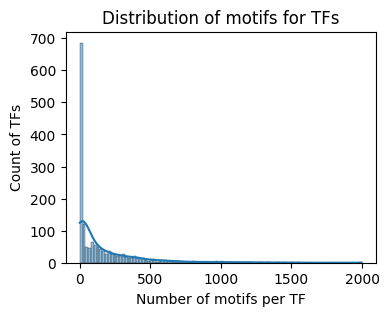

In [48]:
motifs_info = pd.read_csv(par['motifs_info'], sep='\t')
motifs_info = motifs_info[['#motif_id', 'gene_name']].rename(columns={'#motif_id': 'motif', 'gene_name': 'tf'})

print(f"Number of motifs: {motifs_info['motif'].nunique()}, Number of TFs: {motifs_info['tf'].nunique()}")

motif_counts = motifs_info.groupby("tf").size()

# Plot the distribution
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

sns.histplot(motif_counts, bins=100, kde=True, ax=ax)
ax.set_xlabel("Number of motifs per TF")
ax.set_ylabel("Count of TFs")
ax.set_title("Distribution of motifs for TFs")


plt.show()

## Stats of regions to promotors

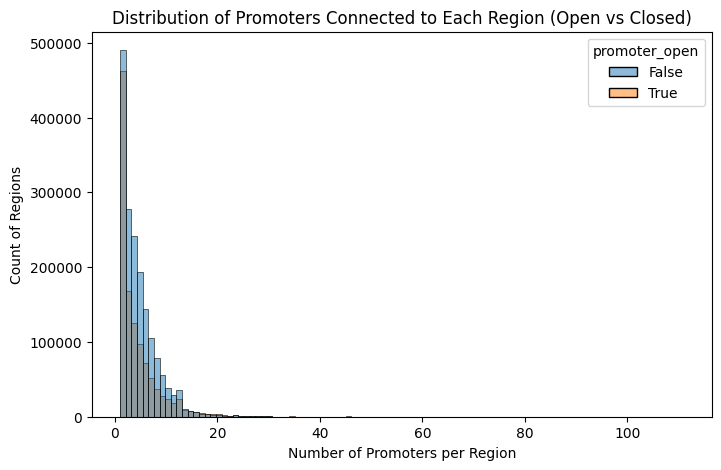

In [ ]:
regions2promoters = pd.read_csv(par['regions2promoters'])
promoter_counts = regions2promoters.groupby(["region", "promoter_open"]).size().reset_index(name="count")

# Plot the distribution, separating open vs. closed promoters
plt.figure(figsize=(8, 5))
sns.histplot(
    data=promoter_counts, 
    x="count", 
    hue="promoter_open", 
    bins=100, 
    alpha=0.5,
    # kde=True, 
    # element="step"
)

plt.xlabel("Number of Promoters per Region")
plt.ylabel("Count of Regions")
plt.title("Distribution of Promoters Connected to Each Region (Open vs Closed)")
plt.show()

## TF gene connections

## Co-access 

In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.metrics.pairwise import cosine_similarity

# Load or preprocess scATAC-seq data
adata = sc.read_h5ad(par['atac'])  # Or other formats

# Ensure the matrix is binary (0: no accessibility, 1: accessible)
adata.X = (adata.X > 0).astype(int)

print(adata)

AnnData object with n_obs × n_vars = 25551 × 135358
    obs: 'cell_type', 'donor_id'
    var: 'seqname', 'ranges', 'strand'
    uns: 'data_reference', 'data_url', 'dataset_description', 'dataset_id', 'dataset_name', 'dataset_organism', 'dataset_summary', 'normalization_id'
    layers: 'counts'


In [5]:
from sklearn.decomposition import TruncatedSVD

# Perform TF-IDF normalization
tf_idf = adata.X.multiply(1 / (adata.X.sum(axis=1) + 1e-6))  # Avoid division by zero

# Reduce dimensions with SVD (similar to LSI in Cicero)
svd = TruncatedSVD(n_components=30)  # Adjust components based on variance explained
lsi_components = svd.fit_transform(tf_idf)

adata.obsm["X_lsi"] = lsi_components  # Store in AnnData

In [6]:
sc.pp.neighbors(adata, use_rep="X_lsi", n_neighbors=15, method="umap")

In [8]:
# sc.pl.pca(adata)